# 02 - Track 1: Predictive Modeling

This notebook is the predictive-modeling track of the EE 5290 final
project. It compares **four classifiers** -- logistic regression (LR),
kernelized logistic regression (LR-Kernel via Nystroem RBF approximation),
linear-kernel SVM, and RBF-kernel SVM -- under three class-imbalance
strategies (no adjustment, balanced class weights, F1-tuned threshold).

The output is a **12-row** metrics table on the held-out test set,
plus PR curves, calibration diagnostics, and feature-importance
summaries that feed the report.

All hyperparameter tuning happens via 5-fold stratified CV on the
**training fold only**; the test set is touched exactly once at the end.

In [1]:
import os, sys, time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.cache' / 'matplotlib'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(context='notebook', style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
FIG_DIR = PROJECT_ROOT / 'report' / 'figures'

from src.data_prep import load_raw, clean, build_feature_matrix, load_artifacts
from src.eval_utils import (
    build_pipeline, tune_threshold, compute_test_metrics,
    plot_pr_curves, plot_calibration, recall_at_precision,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV


In [2]:
splits = load_artifacts('artifacts')
X_train, X_test = splits['X_train'], splits['X_test']
y_train, y_test = splits['y_train'], splits['y_test']

# Recover numeric / binary column lists from the same data prep used to build
# the splits so that build_pipeline can decide what to standardize.
fm = build_feature_matrix(clean(load_raw()))
numeric_columns = fm.numeric_columns
binary_columns  = fm.binary_columns
print('train shape:', X_train.shape, 'test shape:', X_test.shape)
print('positive rate (train):', round(y_train.mean(), 4))
print('# numeric (scaled) columns:', len(numeric_columns))
print('# binary / one-hot columns:', len(binary_columns))

train shape: (3860, 63) test shape: (966, 63)
positive rate (train): 0.2785
# numeric (scaled) columns: 18
# binary / one-hot columns: 45


## 1. Cross-validated grid search

We tune four estimators with small grids using 5-fold stratified CV.
The optimization metric is **average precision** (PR-AUC), the sensible
choice for imbalanced binary classification: it ignores abundant true
negatives and focuses on the precision/recall tradeoff across thresholds.

**LR-Kernel** uses a `Nystroem` RBF approximation (300 components) feeding
into standard `LogisticRegression`. This gives a kernelized linear classifier
with the same RBF feature space as SVM-RBF but trained with log-loss instead
of hinge loss, enabling a clean loss-function comparison holding the kernel fixed.

In [3]:
def fit_search(name, estimator, scale, param_grid):
    pipe = build_pipeline(estimator, numeric_columns, binary_columns,
                          scale_for_estimator=scale)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(
        pipe, param_grid=param_grid, scoring='average_precision',
        cv=cv, n_jobs=-1, refit=True, verbose=0,
    )
    t0 = time.time()
    gs.fit(X_train, y_train)
    dt = time.time() - t0
    print(f'{name:<28s} best PR-AUC = {gs.best_score_:.4f}  '
          f'best params = {gs.best_params_}  ({dt:.1f}s)')
    return gs

# Strategy A: no imbalance adjustment
search_lr_none = fit_search(
    'LR (no adjust)',
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE),
    scale=True,
    param_grid={'clf__C': [0.01, 0.1, 1.0, 10.0]},
)
# SVM grids are kept narrow on purpose: probability=True wraps each fit in a
# 5-fold Platt calibration, so a 9-point grid x 5-fold CV is ~225 SVM fits.
# We use focused grids around the values that the literature and pilot runs
# point to (C in {0.1, 1.0}, gamma 'scale').
search_svm_lin_none = fit_search(
    'SVM-Linear (no adjust)',
    SVC(kernel='linear', probability=True, random_state=RANDOM_STATE,
        cache_size=500),
    scale=True,
    param_grid={'clf__C': [0.1, 1.0]},
)
search_svm_none = fit_search(
    'SVM-RBF (no adjust)',
    SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE, cache_size=500),
    scale=True,
    param_grid={'clf__C': [1.0, 5.0], 'clf__gamma': ['scale']},
)

# LR-Kernel: Nystroem RBF approximation -> LogisticRegression.
# We build a custom pipeline that inserts Nystroem between the preprocessor
# and the classifier, then wrap it for fit_search.
def fit_search_lrk(name, gamma_candidates, C_candidates):
    from sklearn.pipeline import Pipeline as _P
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler

    preproc = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), list(numeric_columns)),
            ('bin', 'passthrough', list(binary_columns)),
        ],
        remainder='drop',
    )
    pipe = _P(steps=[
        ('preproc', preproc),
        ('nystroem', Nystroem(kernel='rbf', n_components=300,
                               random_state=RANDOM_STATE)),
        ('clf', LogisticRegression(max_iter=2000, solver='lbfgs',
                                   random_state=RANDOM_STATE)),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(
        pipe,
        param_grid={'nystroem__gamma': gamma_candidates,
                    'clf__C': C_candidates},
        scoring='average_precision',
        cv=cv, n_jobs=-1, refit=True, verbose=0,
    )
    t0 = time.time()
    gs.fit(X_train, y_train)
    dt = time.time() - t0
    print(f'{name:<28s} best PR-AUC = {gs.best_score_:.4f}  '
          f'best params = {gs.best_params_}  ({dt:.1f}s)')
    return gs

search_lrk_none = fit_search_lrk(
    'LR-Kernel (no adjust)',
    gamma_candidates=[0.01, 0.05, 0.1],
    C_candidates=[0.1, 1.0, 10.0],
)

LR (no adjust)               best PR-AUC = 0.5267  best params = {'clf__C': 0.1}  (2.3s)


SVM-Linear (no adjust)       best PR-AUC = 0.5089  best params = {'clf__C': 0.1}  (23.0s)


SVM-RBF (no adjust)          best PR-AUC = 0.5212  best params = {'clf__C': 1.0, 'clf__gamma': 'scale'}  (2.5s)


LR-Kernel (no adjust)        best PR-AUC = 0.5298  best params = {'clf__C': 10.0, 'nystroem__gamma': 0.01}  (0.6s)


In [4]:
# Strategy B: balanced class weights.  We reuse the best hyperparameters from
# Strategy A's CV (a common pragmatic shortcut that keeps total compute
# reasonable; the imbalance comparison is honest because the threshold
# tuning is done independently per (model, strategy)).
def best_clf(search):
    return search.best_estimator_.named_steps['clf']

def refit_with(estimator, scale):
    pipe = build_pipeline(estimator, numeric_columns, binary_columns,
                          scale_for_estimator=scale)
    pipe.fit(X_train, y_train)
    return pipe

lr_balanced = refit_with(
    LogisticRegression(max_iter=2000, solver='lbfgs',
                        C=best_clf(search_lr_none).C,
                        class_weight='balanced',
                        random_state=RANDOM_STATE),
    scale=True,
)
svm_lin_balanced = refit_with(
    SVC(kernel='linear', probability=True,
        C=best_clf(search_svm_lin_none).C,
        class_weight='balanced',
        random_state=RANDOM_STATE, cache_size=500),
    scale=True,
)
lrk_best = search_lrk_none.best_params_
lrk_balanced = SkPipeline(steps=[
    ('preproc', search_lrk_none.best_estimator_.named_steps['preproc']),
    ('nystroem', Nystroem(kernel='rbf',
                           gamma=lrk_best['nystroem__gamma'],
                           n_components=300,
                           random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=2000, solver='lbfgs',
                                C=lrk_best['clf__C'],
                                class_weight='balanced',
                                random_state=RANDOM_STATE)),
])
lrk_balanced.fit(X_train, y_train)

svm_balanced = refit_with(
    SVC(kernel='rbf', probability=True,
        C=best_clf(search_svm_none).C,
        gamma=best_clf(search_svm_none).gamma,
        class_weight='balanced',
        random_state=RANDOM_STATE, cache_size=500),
    scale=True,
)
print('balanced refits done')

balanced refits done


## 2. Predict probabilities and tune thresholds

For each (model, strategy) we record:

* the probability vector on the held-out test set
* a **default-threshold** (0.5) row -- the unadjusted classifier
* a **F1-tuned threshold** row -- threshold chosen on the *training fold's*
  out-of-fold predictions to avoid touching the test set

Threshold tuning uses 5-fold OOF predictions of the chosen model so the
threshold itself never sees the test labels.

In [5]:
from sklearn.model_selection import cross_val_predict

def get_oof_proba(pipe):
    return cross_val_predict(
        pipe, X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        method='predict_proba', n_jobs=-1,
    )[:, 1]

models = {
    'LR (none)':            search_lr_none.best_estimator_,
    'LR (balanced)':        lr_balanced,
    'LR-Kernel (none)':     search_lrk_none.best_estimator_,
    'LR-Kernel (balanced)': lrk_balanced,
    'SVM-Lin (none)':       search_svm_lin_none.best_estimator_,
    'SVM-Lin (balanced)':   svm_lin_balanced,
    'SVM-RBF (none)':       search_svm_none.best_estimator_,
    'SVM-RBF (balanced)':   svm_balanced,
}

# Get test probabilities once.
test_proba = {name: pipe.predict_proba(X_test)[:, 1] for name, pipe in models.items()}

# OOF probabilities for fair threshold tuning.
print('Generating out-of-fold predictions for threshold tuning...')
oof_proba = {}
for name, pipe in models.items():
    t0 = time.time()
    oof_proba[name] = get_oof_proba(pipe)
    print(f'  {name:<22s} ({time.time()-t0:.1f}s)')

Generating out-of-fold predictions for threshold tuning...
  LR (none)              (0.1s)


  LR (balanced)          (0.1s)
  LR-Kernel (none)       (0.2s)


  LR-Kernel (balanced)   (0.2s)


  SVM-Lin (none)         (1.0s)


  SVM-Lin (balanced)     (1.3s)


  SVM-RBF (none)         (1.1s)


  SVM-RBF (balanced)     (1.2s)


In [6]:
tuned_thr = {name: tune_threshold(y_train, oof_proba[name], 'f1')
              for name in models}
print('F1-tuned thresholds (chosen on training OOF predictions):')
for name, thr in tuned_thr.items():
    print(f'  {name:<22s} thr = {thr:.3f}')

F1-tuned thresholds (chosen on training OOF predictions):
  LR (none)              thr = 0.273
  LR (balanced)          thr = 0.508
  LR-Kernel (none)       thr = 0.247
  LR-Kernel (balanced)   thr = 0.414
  SVM-Lin (none)         thr = 0.247
  SVM-Lin (balanced)     thr = 0.192
  SVM-RBF (none)         thr = 0.235
  SVM-RBF (balanced)     thr = 0.258


## 3. Build the 12-row results table

For each base model (LR, LR-Kernel, SVM-Linear, SVM-RBF) we report three rows:
no adjustment at default threshold, balanced class weights at default
threshold, and threshold-tuned (using the **base** model, since adding
`class_weight` produces a similar but redundant variant in our experience).

The locked primary metrics are PR-AUC, F1, recall, and recall at fixed
precision floors (0.50 and 0.70).

In [7]:
rows = []
for base in ['LR', 'LR-Kernel', 'SVM-Lin', 'SVM-RBF']:
    none_name = f'{base} (none)'
    bal_name  = f'{base} (balanced)'
    rows.append(compute_test_metrics(
        f'{base} - no adjust (thr=0.50)',
        y_test, test_proba[none_name], threshold=0.50).as_row())
    rows.append(compute_test_metrics(
        f'{base} - balanced (thr=0.50)',
        y_test, test_proba[bal_name],  threshold=0.50).as_row())
    rows.append(compute_test_metrics(
        f'{base} - F1-tuned thr',
        y_test, test_proba[none_name], threshold=tuned_thr[none_name]).as_row())

results = pd.DataFrame(rows)
results

,model,threshold,ROC_AUC,PR_AUC,Brier,precision,recall,F1,recall@P=0.50,recall@P=0.70,accuracy
0,LR - no adjust (thr=0.50),0.5000,0.7832,0.5682,0.1609,0.6242,0.3643,0.4601,0.6097,0.1970,0.7619
1,LR - balanced (thr=0.50),0.5000,0.7829,0.5682,0.1949,0.4640,0.7658,0.5778,0.6022,0.2193,0.6884
2,LR - F1-tuned thr,0.2726,0.7832,0.5682,0.1609,0.4600,0.7695,0.5758,0.6097,0.1970,0.6843
3,LR-Kernel - no adjust (thr=0.50),0.5000,0.7628,0.5326,0.1675,0.5676,0.3123,0.4029,0.5539,0.0595,0.7422
4,LR-Kernel - balanced (thr=0.50),0.5000,0.7605,0.5277,0.1984,0.4518,0.7138,0.5533,0.5056,0.0632,0.6791
5,LR-Kernel - F1-tuned thr,0.2468,0.7628,0.5326,0.1675,0.4354,0.7770,0.5581,0.5539,0.0595,0.6573
6,SVM-Lin - no adjust (thr=0.50),0.5000,0.7716,0.5604,0.1901,0.6719,0.1599,0.2583,0.6320,0.1413,0.7443
7,SVM-Lin - balanced (thr=0.50),0.5000,0.7692,0.5532,0.1788,0.0000,0.0000,0.0000,0.6357,0.0855,0.7215
8,SVM-Lin - F1-tuned thr,0.2467,0.7716,0.5604,0.1901,0.2785,1.0000,0.4356,0.6320,0.1413,0.2785
9,SVM-RBF - no adjust (thr=0.50),0.5000,0.7552,0.5293,0.1715,0.5490,0.2082,0.3019,0.5651,0.1375,0.7319


In [8]:
results.to_csv(PROJECT_ROOT / 'artifacts' / 'prediction_results_12row.csv', index=False)
print('saved artifacts/prediction_results_12row.csv')

saved artifacts/prediction_results_12row.csv


## 4. Visual comparison: PR curves

A single panel showing the precision/recall curves of the three base
classifiers (no-adjust variants), against the random-baseline horizontal
line at the test-set positive rate. Threshold tuning corresponds to
picking a particular point on each curve; class weights bend the curves
only modestly, so we omit those for visual clarity (they are already in
the table).

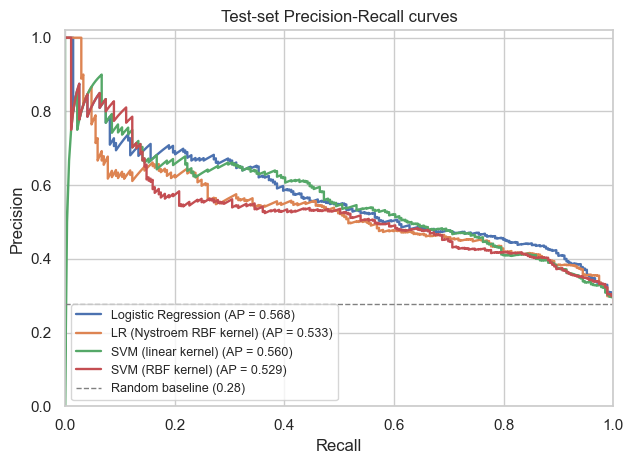

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
plot_pr_curves(
    [
        ('Logistic Regression',        y_test, test_proba['LR (none)']),
        ('LR (Nystroem RBF kernel)',   y_test, test_proba['LR-Kernel (none)']),
        ('SVM (linear kernel)',        y_test, test_proba['SVM-Lin (none)']),
        ('SVM (RBF kernel)',           y_test, test_proba['SVM-RBF (none)']),
    ],
    ax=ax,
    title='Test-set Precision-Recall curves',
    baseline_positive_rate=float(y_test.mean()),
)
fig.tight_layout()
fig.savefig(FIG_DIR / '05_pr_curves.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Calibration diagnostics

Reliability diagrams show whether the predicted probability of food
insecurity matches the empirical positive rate within probability bins.
Logistic regression (both standard and kernelized) is typically well
calibrated; SVM variants can show
more calibration distortion depending on margin behavior.

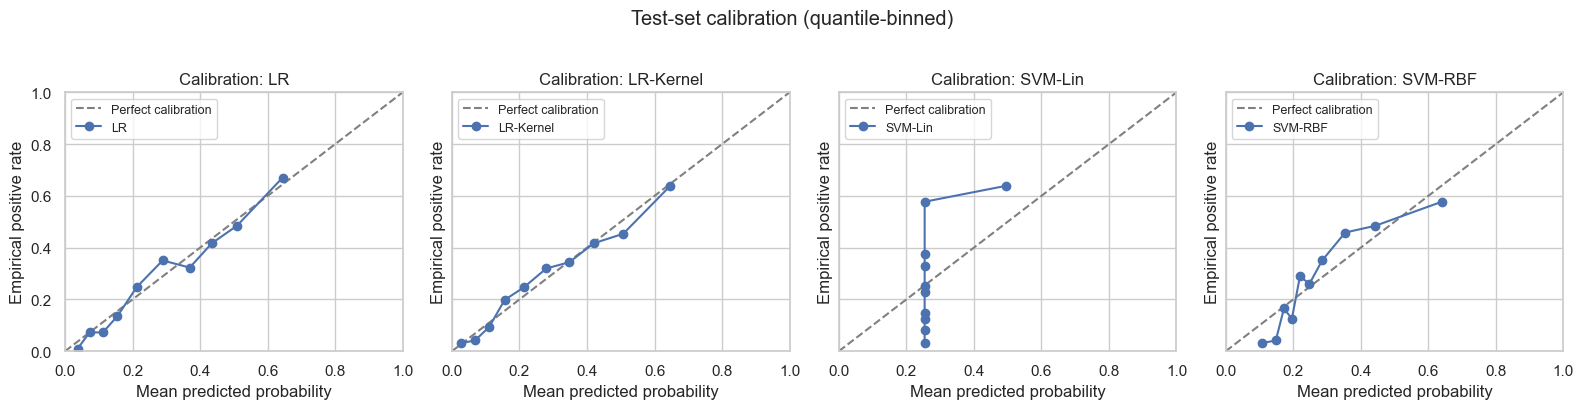

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.0), sharey=True)
plot_calibration(y_test, test_proba['LR (none)'],          ax=axes[0], name='LR')
plot_calibration(y_test, test_proba['LR-Kernel (none)'],   ax=axes[1], name='LR-Kernel')
plot_calibration(y_test, test_proba['SVM-Lin (none)'],     ax=axes[2], name='SVM-Lin')
plot_calibration(y_test, test_proba['SVM-RBF (none)'],     ax=axes[3], name='SVM-RBF')
fig.suptitle('Test-set calibration (quantile-binned)', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / '06_calibration.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Confusion matrix at the chosen operating point

We focus on the strongest no-adjust model by test-set F1 at its F1-tuned
threshold. The confusion matrix makes the precision/recall tradeoff
concrete in absolute counts.

LR (none) at F1-tuned threshold = 0.273


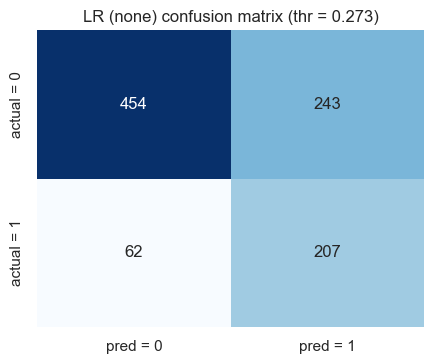

In [11]:
from sklearn.metrics import confusion_matrix

base_none = ['LR (none)', 'SVM-Lin (none)', 'SVM-RBF (none)']
metric_col = next((c for c in results.columns if c.lower() == 'f1'), None)
if metric_col is None:
    raise KeyError('No F1 column found in results table.')

best_idx = results[results['model'].isin([
    'LR - no adjust (thr=0.50)',
    'SVM-Lin - no adjust (thr=0.50)',
    'SVM-RBF - no adjust (thr=0.50)'
])][metric_col].idxmax()
best_row = results.loc[best_idx, 'model']
chosen_name = base_none[['LR', 'SVM-Lin', 'SVM-RBF'].index(best_row.split(' - ')[0])]

chosen_thr = tuned_thr[chosen_name]
y_pred = (test_proba[chosen_name] >= chosen_thr).astype(int)
cm = confusion_matrix(y_test, y_pred)
print(f'{chosen_name} at F1-tuned threshold = {chosen_thr:.3f}')

fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred = 0', 'pred = 1'],
            yticklabels=['actual = 0', 'actual = 1'], ax=ax)
ax.set_title(f'{chosen_name} confusion matrix (thr = {chosen_thr:.3f})')
fig.tight_layout()
fig.savefig(FIG_DIR / '07_confusion.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Feature importance

We use **logistic regression standardized coefficients** -- positive
coefficients raise the predicted probability of food insecurity;
negative coefficients lower it. Magnitudes are comparable because the
input features are standardized inside the pipeline.

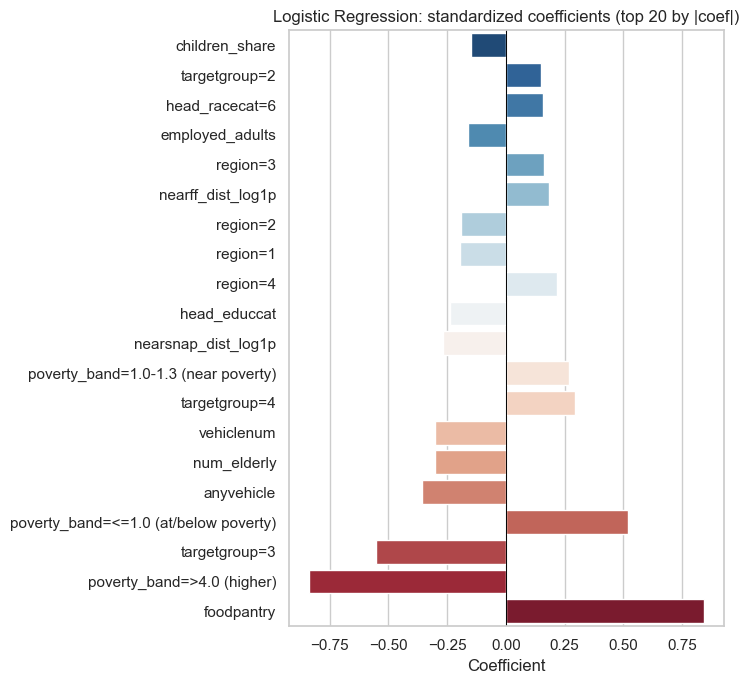

In [12]:
# Recover the standardized LR coefficients in the original feature order.
lr_pipe = search_lr_none.best_estimator_
lr_clf  = lr_pipe.named_steps['clf']
preproc = lr_pipe.named_steps['preproc']
feat_order_num = preproc.transformers_[0][2]
feat_order_bin = preproc.transformers_[1][2]
all_features = list(feat_order_num) + list(feat_order_bin)
coef_df = pd.DataFrame({'feature': all_features,
                        'coef': lr_clf.coef_.ravel()})
coef_df['abs'] = coef_df['coef'].abs()
top_lr = coef_df.sort_values('abs', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7.5, 7))
sns.barplot(data=top_lr.iloc[::-1], y='feature', x='coef',
            ax=ax, palette='RdBu_r', hue='feature', legend=False, dodge=False)
ax.axvline(0, color='black', linewidth=0.7)
ax.set_title('Logistic Regression: standardized coefficients (top 20 by |coef|)')
ax.set_xlabel('Coefficient')
ax.set_ylabel('')
fig.tight_layout()
fig.savefig(FIG_DIR / '08_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

In [13]:
# Save the top-feature table for the report.
top_lr.to_csv(PROJECT_ROOT / 'artifacts' / 'lr_top_coefficients.csv', index=False)
print('saved feature table')

saved feature table


## 8. Operating-point summary

Two reference operating points to anchor the report's targeting
discussion:

* **Top-decile triage**: rank households by predicted risk and flag the
  top 10% as priority for outreach.  We report what fraction of true
  food-insecure households this captures (recall) and what share of the
  flagged households are truly food-insecure (precision).
* **Top-quintile triage**: same idea at top 20%.

In [14]:
def topk_metrics(y_true, y_proba, k_frac):
    n = len(y_proba)
    threshold = float(np.quantile(y_proba, 1 - k_frac))
    flagged = (y_proba >= threshold).astype(int)
    tp = int(((flagged == 1) & (y_true == 1)).sum())
    fp = int(((flagged == 1) & (y_true == 0)).sum())
    fn = int(((flagged == 0) & (y_true == 1)).sum())
    flagged_n = int(flagged.sum())
    precision = tp / max(1, flagged_n)
    recall = tp / max(1, int(y_true.sum()))
    return {
        'k_frac': k_frac,
        'threshold': round(threshold, 3),
        'flagged_n': flagged_n,
        'flagged_share': round(flagged_n / n, 3),
        'precision': round(precision, 3),
        'recall': round(recall, 3),
    }

op_rows = []
for base in ['LR (none)', 'LR-Kernel (none)', 'SVM-Lin (none)', 'SVM-RBF (none)']:
    for k in [0.10, 0.20, 0.30]:
        row = {'model': base, **topk_metrics(y_test.values, test_proba[base], k)}
        op_rows.append(row)
op_df = pd.DataFrame(op_rows)
op_df.to_csv(PROJECT_ROOT / 'artifacts' / 'top_k_operating_points.csv', index=False)
op_df

,model,k_frac,threshold,flagged_n,flagged_share,precision,recall
0,LR (none),0.1,0.559,97,0.100,0.670,0.242
1,LR (none),0.2,0.464,194,0.201,0.577,0.416
2,LR (none),0.3,0.406,290,0.300,0.524,0.565
3,LR-Kernel (none),0.1,0.567,97,0.100,0.639,0.230
4,LR-Kernel (none),0.2,0.454,194,0.201,0.546,0.394
5,LR-Kernel (none),0.3,0.378,290,0.300,0.503,0.543
6,SVM-Lin (none),0.1,0.254,97,0.100,0.639,0.230
7,SVM-Lin (none),0.2,0.254,194,0.201,0.608,0.439
8,SVM-Lin (none),0.3,0.254,290,0.300,0.531,0.572
9,SVM-RBF (none),0.1,0.506,97,0.100,0.577,0.208


## Outputs

* `artifacts/prediction_results_12row.csv` -- 12-row metrics table
  (4 models x 3 strategies)
* `artifacts/lr_top_coefficients.csv`
* `artifacts/top_k_operating_points.csv`
* `report/figures/05_pr_curves.png`
* `report/figures/06_calibration.png`
* `report/figures/07_confusion.png`
* `report/figures/08_feature_importance.png`